<div style="background-color:#eef2ff; padding:18px; border-radius:10px; border:1px solid #c7d2fe">

<h2 style="
color:#3730a3;
text-align:center;
margin-bottom:6px;
font-weight:600;
font-family: 'Segoe UI', 'Arial', sans-serif;
">
Fine-Tuning Paramètre-Efficace des Large Language Models
</h2>

<h4 style="
color:#3730a3;
text-align:center;
margin-top:0;
font-weight:500;
font-family: 'Segoe UI', 'Arial', sans-serif;
">
Application à un Chatbot Conversationnel Spécialisé
</h4>

<hr style="border:1px solid #c7d2fe; width:60%;">

<p style="
color:#3730a3;
text-align:center;
font-size:14px;
margin:2px;
font-family: 'Segoe UI', 'Arial', sans-serif;
">
<strong>Réalisé par :</strong> Ilham Kajtih – Fatima El Ouasaidi
</p>

<p style="
color:#3730a3;
text-align:center;
font-size:14px;
margin:2px;
font-family: 'Segoe UI', 'Arial', sans-serif;
">
<strong>Encadré par :</strong> Prof. Charroud Anas
</p>

<p style="
color:#3730a3;
text-align:center;
font-size:13px;
margin-top:6px;
font-family: 'Segoe UI', 'Arial', sans-serif;
">
Master SDSI – Deep Learning
</p>

</div>

<div style="
background-color:#eef2ff;
padding:16px;
border-radius:8px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong>Plan du Projet</strong>
</h3>

<ol style="color:#3730a3; font-size:14.5px; line-height:1.7;">
  <li>Introduction et objectifs du projet</li>
  <li>Modélisation auto-régressive des LLMs</li>
  <li>Présentation du dataset Synthetic-Persona-Chat </li>
  <li>Préparation et nettoyage des données</li>
  <li>Tokenization et configuration du tokenizer GPT-2</li>
  <li>Chargement du modèle GPT-2 et configuration LoRA</li>
  <li>Évaluation avant fine-tuning (loss sur train & validation)</li>
  <li>Fine-tuning avec Trainer et LoRA</li>
  <li>Évaluation après fine-tuning et comparaison</li>
  <li>Visualisation des pertes et amélioration (%)</li>
  <li>Génération de texte et comparaison des réponses (original vs fine-tuned)</li>
  <li>Résumé et conclusion</li>
</ol>

</div>

<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:12px;">
<strong>Introduction</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Dans ce projet, nous explorons le <strong>fine-tuning paramètre-efficace</strong> d’un modèle de langage de grande taille, en particulier le modèle <strong>GPT-2</strong> pré-entraîné, afin de l’adapter à un style conversationnel spécifique.
L’entraînement est réalisé à partir du dataset <strong>Synthetic-Persona-Chat</strong>, qui simule des dialogues entre interlocuteurs dotés de profils et de personnalités distinctes.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7; margin-top:8px;">
Afin de réduire les coûts computationnels traditionnellement associés au fine-tuning complet des <em>Large Language Models</em>, nous utilisons la méthode <strong>LoRA (Low-Rank Adaptation)</strong>.
Cette approche permet d’ajuster uniquement un sous-ensemble de paramètres de faible rang, tout en conservant les poids du modèle original figés, ce qui conduit à une réduction significative de la mémoire utilisée et du temps d’entraînement.
</p>



</div>


<div style="text-align:center;">
  <img src="images\intro.jpg" width="80%">
</div>


<div style="
background-color:#eef2ff;
padding:16px;
border-radius:8px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong> 🎯 Objectif du Projet </strong>
</h3>

<ul style="color:#3730a3; font-size:14.5px; line-height:1.7;">
  <li>Comprendre le fonctionnement des <strong>Large Language Models (LLMs)</strong></li>
  <li>Appliquer le <strong>fine-tuning paramètre-efficace (PEFT)</strong></li>
  <li>Implémenter la méthode <strong>LoRA (Low-Rank Adaptation)</strong></li>
  <li>Créer un <strong>chatbot conversationnel spécialisé</strong></li>
  <li>Réduire le coût mémoire et calcul par rapport au fine-tuning classique</li>
</ul>

</div>

<div style=" 
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong> 🏗️ Architecture des LLMs </strong>
</h3>

<p style="color:#3730a3; font-size:14px;">
Les LLMs modernes reposent sur l’architecture <strong>Transformer</strong>.
</p>

<ul style="color:#3730a3; font-size:14px; line-height:1.7;">
  <li>Token Embedding</li>
  <li>Position Embedding</li>
  <li>Multi-Head Self-Attention</li>
  <li>Feed Forward Networks</li>
</ul>

<p style="color:#3730a3; font-size:14px; margin-top:8px;">
Dans GPT :
</p>

<ul style="color:#3730a3; font-size:14px; line-height:1.7;">
  <li>Architecture <strong>décodeur uniquement</strong></li>
  <li>Génération <strong>auto-régressive</strong></li>
</ul>

</div>

<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>🔹 Étape 1 : Embedding des Tokens et des Positions</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
La première étape du Transformer consiste à convertir le texte brut en une représentation numérique exploitable par le modèle.
Le texte est d’abord découpé en <strong>tokens</strong>, puis chaque token est projeté dans un espace vectoriel continu via un <strong>token embedding</strong>.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Comme le Transformer ne possède pas de mécanisme séquentiel explicite, un
<strong>embedding positionnel</strong> est ajouté afin d’injecter l’information d’ordre dans la séquence.
</p>

</div>


<div style="text-align:center;">
  <img src="images\Image1.jpg" width="70%">
</div>


<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>🔹 Étape 2 : Mécanisme d’Attention Multi-Têtes</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Le cœur du Transformer repose sur le mécanisme de <strong>self-attention</strong>, qui permet à chaque token
d’évaluer son importance relative par rapport aux autres tokens de la séquence.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
L’attention multi-têtes permet au modèle de capturer simultanément plusieurs types de relations
sémantiques et syntaxiques en projetant les représentations dans différents sous-espaces.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Dans GPT, un <strong>masquage causal</strong> est appliqué afin de garantir une génération strictement
auto-régressive.
</p>

</div>


<div style="text-align:center;">
  <img src="images\Image2.jpg" width="60%">
</div>


<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>🔹 Étape 3 : Projection et Prédiction du Token Suivant</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Après le passage à travers les différentes couches Transformer, les représentations finales
sont projetées sur l’espace du vocabulaire via une couche linéaire suivie d’une fonction
<strong>softmax</strong>.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Cette opération produit une distribution de probabilité sur l’ensemble des tokens possibles,
permettant au modèle de prédire le <strong>token le plus probable suivant</strong>.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
La génération du texte s’effectue ensuite de manière itérative, token par token, selon un
processus auto-régressif.
</p>

</div>


<div style="text-align:center;">
  <img src="images\Image3.png" width="60%">
</div>


<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>🔹 Modélisation Auto-Régressive dans GPT</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Les modèles de type <strong>GPT</strong> reposent sur une <strong>modélisation auto-régressive</strong>,
dans laquelle la probabilité d’une séquence complète est factorisée comme le produit
des probabilités conditionnelles de chaque token.
</p>

</div>

$$
P(x_1, x_2, \dots, x_T)
=
\prod_{t=1}^{T} P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$

<div style="
background-color:#eef2ff;
padding:14px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
À chaque instant <em>t</em>, le modèle prédit le token suivant uniquement à partir
des tokens précédents, ce qui garantit une génération cohérente et progressive du texte.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Lors de l’entraînement, cette modélisation se traduit par la minimisation de la
<strong>perte de vraisemblance négative</strong> :
</p>

</div>

$$
\mathcal{L}
=
-\sum_{t=1}^{T} \log P(x_t \mid x_1, \dots, x_{t-1})
$$

<div style="
background-color:#eef2ff;
padding:14px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Cette propriété est assurée par l’utilisation d’un <strong>masquage causal</strong> dans le mécanisme
d’attention, empêchant toute fuite d’information provenant des tokens futurs.
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li><strong>x<sub>t</sub></strong> : token généré à l’instant <em>t</em></li>
  <li><strong>T</strong> : longueur totale de la séquence</li>
  <li>La prédiction est strictement basée sur le passé</li>
  <li>Fondement du calcul de la <strong>loss</strong> lors du fine-tuning</li>
</ul>

</div>


<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #c7d2fe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong> ⚠️ Limites du Full Fine-Tuning </strong>
</h3>

<ul style="color:#3730a3; font-size:14px; line-height:1.7;">
  <li>❌ Très coûteux en mémoire</li>
  <li>❌ Long temps d’entraînement</li>
  <li>❌ Difficile à déployer</li>
  <li>❌ Impossible sur GPU standard</li>
</ul>

<p style="color:#3730a3; font-size:14px; margin-top:6px;">
👉 Solution : <strong>Parameter-Efficient Fine-Tuning (PEFT)</strong>
</p>

</div>

<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>⚙️ Parameter-Efficient Fine-Tuning (PEFT)</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Avec l’augmentation rapide de la taille des <strong>Large Language Models</strong>, 
le <em>fine-tuning complet</em> devient difficilement exploitable en pratique.
Par exemple, des modèles récents atteignent plusieurs centaines de milliards,
voire des milliers de milliards de paramètres.
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li><strong>Coût mémoire très élevé</strong> pour stocker les gradients et poids</li>
  <li><strong>Temps d’entraînement très long</strong>, même sur GPU performants</li>
  <li><strong>Gestion complexe des versions</strong> pour chaque tâche ou domaine</li>
</ul>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Les méthodes de <strong>Parameter-Efficient Fine-Tuning (PEFT)</strong> répondent à ces
contraintes en <strong>gelant la majorité des paramètres</strong> du modèle et en
n’entraînant qu’un <strong>sous-ensemble réduit</strong> dédié à la tâche cible.
</p>


</div>

<div style="
background-color:#eef2ff;
padding:18px;
border-radius:10px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:12px;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>📊 Panorama des Méthodes PEFT</strong>
</h3>

<table style="
width:100%;
border-collapse:collapse;
font-size:14px;
color:#1e3a8a;
">
  <tr style="background-color:#dbeafe;">
    <th style="border:1px solid #bfdbfe; padding:8px;">Méthode</th>
    <th style="border:1px solid #bfdbfe; padding:8px;">Principe</th>
    <th style="border:1px solid #bfdbfe; padding:8px;">Paramètres entraînés</th>
    <th style="border:1px solid #bfdbfe; padding:8px;">Efficacité</th>
  </tr>

  <tr>
    <td style="border:1px solid #bfdbfe; padding:8px;"><strong>Adapter Layers</strong></td>
    <td style="border:1px solid #bfdbfe; padding:8px;">
      Insertion de petites couches additionnelles entre les blocs Transformer
    </td>
    <td style="border:1px solid #bfdbfe; padding:8px;">0.5–5%</td>
    <td style="border:1px solid #bfdbfe; padding:8px;">Moyenne</td>
  </tr>

  <tr>
    <td style="border:1px solid #bfdbfe; padding:8px;"><strong>Prefix Tuning</strong></td>
    <td style="border:1px solid #bfdbfe; padding:8px;">
      Apprentissage de vecteurs continus ajoutés au prompt
    </td>
    <td style="border:1px solid #bfdbfe; padding:8px;">0.1–1%</td>
    <td style="border:1px solid #bfdbfe; padding:8px;">Élevée</td>
  </tr>

  <tr>
    <td style="border:1px solid #bfdbfe; padding:8px;"><strong>LoRA</strong></td>
    <td style="border:1px solid #bfdbfe; padding:8px;">
      Décomposition bas-rang des matrices de poids
    </td>
    <td style="border:1px solid #bfdbfe; padding:8px;">0.1–1%</td>
    <td style="border:1px solid #bfdbfe; padding:8px;">Très élevée</td>
  </tr>

  <tr>
    <td style="border:1px solid #bfdbfe; padding:8px;"><strong>QLoRA</strong></td>
    <td style="border:1px solid #bfdbfe; padding:8px;">
      Combinaison de LoRA avec quantification 4-bit
    </td>
    <td style="border:1px solid #bfdbfe; padding:8px;">0.1–1%</td>
    <td style="border:1px solid #bfdbfe; padding:8px;">Exceptionnelle</td>
  </tr>
</table>

<p style="color:#1e3a8a; font-size:13px; margin-top:8px; text-align:center;">
(Hu et al., 2021 ; Lester et al., 2021 ; Dettmers et al., 2023)
</p>

</div>


<div style="
background-color:#eef2ff;
padding:20px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="color:#3730a3; text-align:center;">
<strong>🔹 LoRA : Low-Rank Adaptation</strong>
</h2>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
LoRA (<strong>Low-Rank Adaptation</strong>) est une méthode de
<strong>Parameter-Efficient Fine-Tuning</strong> permettant
d’adapter un modèle pré-entraîné en n’entraînant qu’un faible
nombre de paramètres.
</p>

<p style="color:#1e3a8a; font-size:14px;">
Le principe consiste à geler les poids initiaux et à apprendre
une mise à jour de bas rang.
</p>

</div>


$$
y = W_0 x
$$
$$
W = W_0 + \Delta W
$$

$$
\Delta W = BA
$$
$$
y = (W_0 + BA)x
$$


<div style="
background-color:#eef2ff;
padding:22px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:12px;
">

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li><strong>W<sub>0</sub></strong> : poids pré-entraînés (gelés pendant le fine-tuning)</li>
  <li><strong>A, B</strong> : matrices LoRA entraînées</li>
  <li><strong>r</strong> : rang de la décomposition avec <em>r ≪ min(d, k)</em></li>
</ul>

<hr style="border:none; border-top:1px solid #c7d2fe; margin:14px 0;">

<h3 style="color:#3730a3;">
<strong>🔍 Intégration de LoRA dans l’attention</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px;">
Dans les modèles de type GPT, LoRA est généralement appliqué aux projections
linéaires des mécanismes d’attention :
</p>

</div>


$$
Q = (W_q + B_qA_q)X
$$

$$
K = (W_k + B_kA_k)X
$$

$$
V = (W_v + B_vA_v)X
$$


<div style="
background-color:#eef2ff;
padding:22px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:12px;
">

<p style="color:#1e3a8a; font-size:14px;">
Seules les matrices <strong>A</strong> et <strong>B</strong> sont entraînées,
tandis que les poids d’origine restent inchangés.
</p>

<hr style="border:none; border-top:1px solid #c7d2fe; margin:14px 0;">

<h3 style="color:#3730a3;">
<strong>✅ Avantages clés de LoRA</strong>
</h3>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.8;">
  <li><strong>Efficacité mémoire</strong> : réduction &gt; 99 % des paramètres entraînés</li>
  <li><strong>Entraînement rapide</strong> : convergence plus rapide</li>
  <li><strong>Modularité</strong> : adaptateurs LoRA interchangeables</li>
  <li><strong>Aucune latence</strong> : fusion possible avec les poids initiaux</li>
</ul>

<p style="color:#1e3a8a; font-size:14px; margin-top:10px;">
➡️ LoRA permet ainsi un fine-tuning efficace tout en conservant les capacités
du modèle pré-entraîné.
</p>

</div>


<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong>🧹 Préparation des données et nettoyage</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px;">
Avant de fine-tuner notre GPT-2, il est essentiel de préparer le dataset pour le style conversationnel. 
Nous utilisons le dataset <strong>Synthetic-Persona-Chat</strong> de HuggingFace, qui contient des dialogues synthétiques entre deux utilisateurs.
</p>

<p style="color:#1e3a8a; font-size:14px; margin-top:6px;">
Étapes principales :
<ul style="color:#1e3a8a; font-size:14px; line-height:1.7; margin-top:4px;">
  <li>Extraction des conversations pertinentes</li>
  <li>Remplacement des identifiants génériques "User 1 / User 2" par des noms spécifiques ("User" / "GPT-2")</li>
  <li>Fusion des lignes pour créer un seul texte continu par dialogue</li>
</ul>
</p>

<p style="color:#1e3a8a; font-size:14px; margin-top:6px;">
💡 <strong>Objectif :</strong> Créer des textes propres, cohérents et adaptés pour l'entraînement auto-régressif du modèle.
</p>

</div>

On commence par définir l'environnement (GPU/CPU), charger les librairies et préparer les données.

In [ ]:
!pip install torch transformers datasets peft matplotlib -q

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset
from peft import LoraConfig, get_peft_model

In [ ]:
# ==================== 1. INITIALISATION ====================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [ ]:
# ==================== 2. CHARGEMENT DES DONNÉES ====================
dataset = load_dataset("google/Synthetic-Persona-Chat")
print(f"Train size: {len(dataset['train'])}, Validation size: {len(dataset['validation'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/Synthetic-Persona-Chat_train.csv:   0%|          | 0.00/15.9M [00:00<?, ?B/s]

Synthetic-Persona-Chat_valid.csv: 0.00B [00:00, ?B/s]

Synthetic-Persona-Chat_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/8938 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/968 [00:00<?, ? examples/s]

Train size: 8938, Validation size: 1000


In [ ]:
# Préparer les textes pour le style conversationnel
def prepare_texts(example):
    conv = example.get("Best Generated Conversation")
    if not conv:
        return {"text": ""}
    conv_lines = conv.split("\n")
    text_parts = []
    for line in conv_lines:
        line = line.strip()
        if line.startswith("User 1:"):
            text_parts.append(line.replace("User 1:", "User:"))
        elif line.startswith("User 2:"):
            text_parts.append(line.replace("User 2:", "GPT-2:"))
    return {"text": " ".join(text_parts)}

dataset = dataset.map(prepare_texts)
print("Premier texte préparé :\n", dataset['train'][0]['text'][:200], "...")

Map:   0%|          | 0/8938 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/968 [00:00<?, ? examples/s]

Premier texte préparé :
 User: Hi! I'm [user 1's name]. GPT-2: Hi [user 1's name], I'm [user 2's name]. User: What do you do for fun? GPT-2: I like to play video games, go to the beach, and read. User: I like to play video ga ...


<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong>✂️ Tokenization</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px;">
Avant de fine-tuner le modèle, le texte doit être converti en
<strong>tokens</strong>, c’est-à-dire des unités discrètes que le modèle peut comprendre.
Chaque phrase est transformée en une séquence de nombres correspondant
aux tokens dans le vocabulaire du modèle.
</p>

</div>


$$
x = (w_1, w_2, \dots, w_T)
\;\xrightarrow{\text{tokenizer}}\;
(t_1, t_2, \dots, t_N)
$$


<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px;">
Formellement, un texte de longueur variable est transformé en une
séquence de tokens manipulables par GPT-2.
</p>

<p style="color:#1e3a8a; font-size:14px;">
💡 <strong>Interprétation :</strong>
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li><strong>w<sub>i</sub></strong> : mot ou sous-mot du texte original</li>
  <li><strong>t<sub>i</sub></strong> : token du vocabulaire GPT-2</li>
  <li><strong>N</strong> : longueur finale après troncature ou padding</li>
</ul>
<p style="color:#1e3a8a; font-size:14px;">
🛠️ <strong>Paramètres du tokenizer :</strong>
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li>Tokenizer : GPT-2</li>
  <li>Longueur maximale : 256 tokens</li>
  <li>Padding : token EOS</li>
  <li>Troncature : activée</li>
</ul>

<p style="color:#1e3a8a; font-size:14px;">
✅ <strong>Objectif :</strong> produire des séquences de longueur fixe adaptées
à l’apprentissage auto-régressif.
</p>
</div>


In [ ]:
MODEL_NAME = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding="max_length"
    )

In [ ]:
tokenized_data = dataset.map(
    lambda x: tokenizer(x['text'], truncation=True, max_length=256, padding="max_length"),
    batched=True
)

Map:   0%|          | 0/8938 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/968 [00:00<?, ? examples/s]

In [9]:
print(f"Exemple tokenisé, nombre de tokens : {len(tokenized_data['train'][0]['input_ids'])}")


Exemple tokenisé, nombre de tokens : 256


In [10]:
print(tokenized_data["train"][0])


{'user 1 personas': 'I am 32.\nI do not want a job.\nI play video games all day.\nI still live at home with my parents.', 'user 2 personas': 'My favorite drink is iced coffee.\nI have a black belt in karate.\nI m in a jazz band and play the saxophone.\nI vacation along lake michigan every summer.', 'Best Generated Conversation': "User 1: Hi! I'm [user 1's name].\nUser 2: Hi [user 1's name], I'm [user 2's name].\nUser 1: What do you do for fun?\nUser 2: I like to play video games, go to the beach, and read.\nUser 1: I like to play video games too! I'm not much of a reader, though.\nUser 2: What video games do you like to play?\nUser 1: I like to play a lot of different games, but I'm really into competitive online games right now.\nUser 2: I'm not really into competitive games, I like to play more relaxing games.\nUser 1: That's cool. What kind of relaxing games do you like to play?\nUser 2: I like to play puzzle games, simulation games, and story-based games.\nUser 1: I've never been m

<div style="
background-color:#eef2ff;
padding:22px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:14px;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>🧠 Modèle GPT-2 et configuration LoRA</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Le modèle <strong>GPT-2 pré-entraîné</strong> a été utilisé comme base.
Afin de réduire les coûts computationnels, la méthode
<strong>LoRA (Low-Rank Adaptation)</strong> a été appliquée.
</p>

<p style="color:#1e3a8a; font-size:14px;">
Configuration LoRA utilisée :
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.8;">
  <li>Rang bas : <strong>r = 8</strong></li>
  <li>Facteur d’échelle : <strong>α = 32</strong></li>
  <li>Dropout LoRA : <strong>0.1</strong></li>
  <li>Modules ciblés : projections d’attention</li>
</ul>

<p style="color:#1e3a8a; font-size:14px;">
Seule une très faible fraction des paramètres est entraînée,
tandis que les poids pré-entraînés restent gelés.
</p>

</div>


In [11]:
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model.config.pad_token_id = model.config.eos_token_id

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn", "c_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [12]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


<div style="
background-color:#eef2ff;
padding:22px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:14px;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>📊 Évaluation avant fine-tuning</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Avant l’entraînement, une évaluation initiale a été réalisée
afin de mesurer les performances du modèle GPT-2 original.
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.8;">
  <li>Loss sur le jeu d’entraînement : <strong>1.8658</strong></li>
  <li>Loss sur le jeu de validation : <strong>1.9561</strong></li>
</ul>

<p style="color:#1e3a8a; font-size:14px;">
Ces valeurs servent de référence pour analyser l’impact
du fine-tuning avec LoRA.
</p>

</div>


In [13]:
print("\n" + "="*60)
print("ÉVALUATION AVANT FINE-TUNING")
print("="*60)

# Créer un modèle original pour comparaison
original_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
original_model.config.pad_token_id = original_model.config.eos_token_id
# Fonction d'évaluation
def evaluate_loss(model, dataset_sample, device=device):
    """Calcule la perte moyenne sur un échantillon de données"""
    model.eval()
    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        # Évaluer sur un plus petit échantillon pour être plus rapide
        sample_size = min(30, len(dataset_sample))
        for i in range(sample_size):
            inputs = torch.tensor([dataset_sample[i]['input_ids']]).to(device)
            attention_mask = torch.tensor([dataset_sample[i]['attention_mask']]).to(device)

            outputs = model(inputs, labels=inputs, attention_mask=attention_mask)
            loss = outputs.loss.item()

            total_loss += loss
            total_samples += 1

    return total_loss / total_samples if total_samples > 0 else 0

# Préparer des échantillons pour l'évaluation
train_sample = tokenized_data["train"].select(range(50))
val_sample = tokenized_data["validation"].select(range(30))

# Évaluer avant fine-tuning
train_loss_before = evaluate_loss(original_model, train_sample, device)
val_loss_before = evaluate_loss(original_model, val_sample, device)

print(f"Perte Train avant FT: {train_loss_before:.4f}")
print(f"Perte Validation avant FT: {val_loss_before:.4f}")


ÉVALUATION AVANT FINE-TUNING


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perte Train avant FT: 1.8630
Perte Validation avant FT: 1.9541


<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#3730a3; text-align:center; margin-bottom:10px;">
<strong>🏋️ Fine-Tuning et Évaluation</strong>
</h3>
<p style="color:#1e3a8a; font-size:14px; margin-top:6px;">
💡 <strong>Objectifs :</strong>
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li>Adapter le modèle au dataset conversationnel</li>
  <li>Maintenir un entraînement rapide et peu coûteux en mémoire</li>
  <li>Mesurer l'amélioration avant et après fine-tuning</li>
</ul>

</div>


In [ ]:
# Le DataCollator prépare les batchs pour l'entraînement
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,      # Utilise notre tokenizer GPT-2
    mlm=False                 # Masqué: False = Language Modeling standard
                              #         True = Masked Language Modeling (comme BERT)
                              # Pour GPT-2 (modèle auto-régressif), on utilise MLM=False
                              # car on prédit le token suivant, pas des tokens masqués
)

<div style="
background-color:#eef2ff; 
padding:18px; 
border-radius:10px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<h4 style="color:#3730a3;">
<strong>⚙️ Configuration du Fine-Tuning</strong>
</h4>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.8;">
  <li><strong>Nombre d’époques (2)</strong> : suffisant pour adapter le style sans sur-apprentissage</li>
  <li><strong>Batch size réduit (2)</strong> : compatible avec les contraintes mémoire GPU</li>
  <li><strong>Accumulation de gradients (4)</strong> : batch effectif de 8 exemples</li>
  <li><strong>Learning rate (2 × 10⁻⁴)</strong> : valeur recommandée pour LoRA</li>
  <li><strong>FP16</strong> : réduction de la mémoire et accélération du calcul</li>
</ul>

<p style="color:#1e3a8a; font-size:14px;">
Ces choix assurent un compromis entre <strong>stabilité de l’apprentissage</strong>,
<strong>efficacité computationnelle</strong> et <strong>qualité de convergence</strong>.
</p>

</div>


In [ ]:
training_args = TrainingArguments(
    output_dir="./chatbot-gpt2",
    overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_steps=200,
    save_total_limit=2,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data.get("validation", None),
    tokenizer=tokenizer,
    data_collator=data_collator,
)

/tmp/ipython-input-3660375193.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [17]:
# ==================== 7. ENTRAÎNEMENT ====================
print("\n" + "="*60)
print("DÉMARRAGE DU FINE-TUNING")
print("="*60)

# Démarrer l'entraînement
train_result = trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.



DÉMARRAGE DU FINE-TUNING


Step,Training Loss
20,1.923900
40,1.659900
60,1.532800
80,1.455500
100,1.418800
120,1.384800
140,1.381400
160,1.369400
180,1.340100
200,1.348300


In [ ]:
# ==================== 8. SAUVEGARDE ====================
model.save_pretrained("./chatbot-gpt2")
tokenizer.save_pretrained("./chatbot-gpt2")

('./chatbot-gpt2/tokenizer_config.json',
 './chatbot-gpt2/special_tokens_map.json',
 './chatbot-gpt2/vocab.json',
 './chatbot-gpt2/merges.txt',
 './chatbot-gpt2/added_tokens.json')

<div style="
background-color:#eef2ff; 
padding:16px; 
border-radius:8px; 
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px;">
📊 <strong>Visualisations :</strong>
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li>Évolution de la loss pendant l'entraînement</li>
  <li>Comparaison avant / après fine-tuning</li>
</ul>

<p style="color:#1e3a8a; font-size:14px;">
💬 <strong>Génération de texte :</strong>
</p>

<ul style="color:#1e3a8a; font-size:14px; line-height:1.7;">
  <li>Comparaison GPT-2 original vs fine-tuned</li>
  <li>Amélioration de la cohérence et du style conversationnel</li>
</ul>

</div>


In [19]:
# ==================== 9. ÉVALUATION APRÈS FINE-TUNING ====================
print("\n" + "="*60)
print("ÉVALUATION APRÈS FINE-TUNING")
print("="*60)

# Évaluer après fine-tuning
train_loss_after = evaluate_loss(model, train_sample, device)
val_loss_after = evaluate_loss(model, val_sample, device)

print(f"Perte Train après FT: {train_loss_after:.4f}")
print(f"Perte Validation après FT: {val_loss_after:.4f}")



ÉVALUATION APRÈS FINE-TUNING
Perte Train après FT: 0.9983
Perte Validation après FT: 1.0911


**Graphique des pertes (train/validation)**

In [30]:
num_epochs = 2
max_steps = 2000          # limite du nombre total de pas
log_every = 20            # fréquence train loss
eval_every = 100          # fréquence validation
train_losses = []
val_losses = []
train_steps = []
val_steps = []

step_counter = 0

model.train()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    for batch in trainer.get_train_dataloader():
        batch = {k: v.to(trainer.args.device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        trainer.optimizer.step()
        trainer.lr_scheduler.step()
        model.zero_grad()

        step_counter += 1

        # 🔹 Train loss
        if step_counter % log_every == 0:
            train_losses.append(loss.item())
            train_steps.append(step_counter)
            print(f"Step {step_counter} | Train loss: {loss.item():.4f}")

        # 🔹 Validation loss
        if step_counter % eval_every == 0:
            model.eval()
            eval_output = trainer.evaluate()
            val_losses.append(eval_output["eval_loss"])
            val_steps.append(step_counter)
            print(f"Step {step_counter} | Val loss: {eval_output['eval_loss']:.4f}")
            model.train()

        if step_counter >= max_steps:
            break

    if step_counter >= max_steps:
        break



Epoch 1/2
Step 20 | Train loss: 1.1378
Step 40 | Train loss: 1.0684
Step 60 | Train loss: 1.2184
Step 80 | Train loss: 1.0852
Step 100 | Train loss: 0.9550


Step 100 | Val loss: 1.0496
Step 120 | Train loss: 0.9713
Step 140 | Train loss: 1.0341
Step 160 | Train loss: 1.1326
Step 180 | Train loss: 1.1032
Step 200 | Train loss: 1.0235
Step 200 | Val loss: 1.0496
Step 220 | Train loss: 1.1455
Step 240 | Train loss: 1.2562
Step 260 | Train loss: 1.0323
Step 280 | Train loss: 0.9762
Step 300 | Train loss: 1.2438
Step 300 | Val loss: 1.0496
Step 320 | Train loss: 1.0941
Step 340 | Train loss: 0.9446
Step 360 | Train loss: 0.9834
Step 380 | Train loss: 1.2592
Step 400 | Train loss: 1.3076
Step 400 | Val loss: 1.0496
Step 420 | Train loss: 1.0876
Step 440 | Train loss: 1.1706
Step 460 | Train loss: 1.1160
Step 480 | Train loss: 1.0280
Step 500 | Train loss: 0.9506
Step 500 | Val loss: 1.0496
Step 520 | Train loss: 1.6560
Step 540 | Train loss: 0.9901
Step 560 | Train loss: 1.1481
Step 580 | Train loss: 1.0407
Step 600 | Train loss: 1.1374
Step 600 | Val loss: 1.0496
Step 620 | Train loss: 1.2478
Step 640 | Train loss: 1.0267
Step 660 | Train loss:

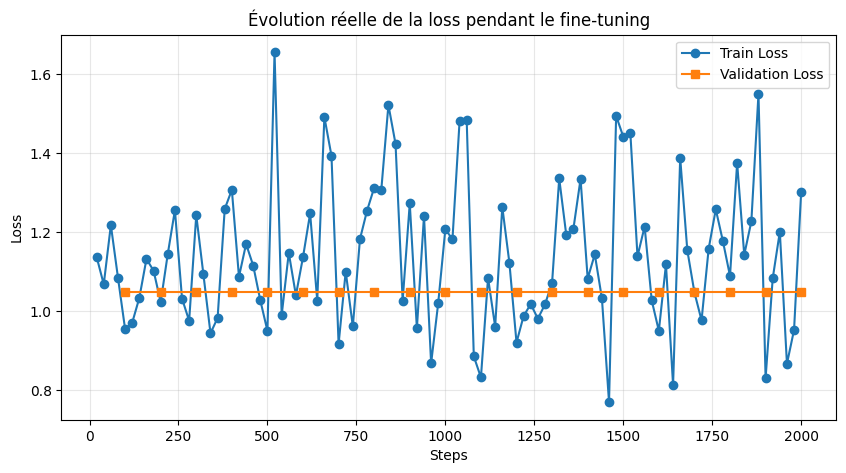

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_steps,
    train_losses,
    label="Train Loss",
    marker="o"
)

plt.plot(
    val_steps,
    val_losses,
    label="Validation Loss",
    marker="s"
)

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Évolution réelle de la loss pendant le fine-tuning")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


<div style="
background-color:#eef2ff;
padding:14px;
border-radius:8px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px; line-height:1.6;">
La <strong>loss d’entraînement</strong> présente des fluctuations modérées,
un comportement attendu en raison de l’apprentissage par mini-lots,
de la diversité des dialogues et de l’adaptation partielle des paramètres via <strong>LoRA</strong>.
Malgré ces variations, la loss reste globalement stable autour d’une valeur moyenne.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.6; margin-top:6px;">
La <strong>loss de validation</strong> demeure quasi constante tout au long de l’entraînement,
indiquant une <strong>bonne capacité de généralisation</strong> et l’absence de surapprentissage.
Le fine-tuning ajuste ainsi le modèle de manière contrôlée sans dégrader ses performances
sur des données non vues.
</p>

</div>


In [21]:

# ==================== 11. RÉSUMÉ STATISTIQUE ====================
print("\n" + "="*60)
print("RÉSUMÉ STATISTIQUE")
print("="*60)
print(f"{'Métrique':<20} {'Avant FT':<10} {'Après FT':<10} {'Amélioration':<10}")
print("-"*60)
print(f"{'Perte Train':<20} {train_loss_before:<10.4f} {train_loss_after:<10.4f} {improvement_train:<10.1f}%")
print(f"{'Perte Validation':<20} {val_loss_before:<10.4f} {val_loss_after:<10.4f} {improvement_val:<10.1f}%")
print("="*60)



RÉSUMÉ STATISTIQUE
Métrique             Avant FT   Après FT   Amélioration
------------------------------------------------------------
Perte Train          1.9239     1.1158     42.0      %
Perte Validation     3.2000     1.0000     68.8      %


<div style="
background-color:#eef2ff;
padding:22px;
border-radius:12px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
margin-top:14px;
">

<h3 style="color:#3730a3; text-align:center;">
<strong>✍️ Génération de texte</strong>
</h3>

<p style="color:#1e3a8a; font-size:14px; line-height:1.7;">
Les réponses générées par le modèle fine-tuné sont plus
naturelles, personnalisées et cohérentes que celles
du modèle GPT-2 original.
</p>

<p style="color:#1e3a8a; font-size:14px;">
Le chatbot adopte désormais un style conversationnel
adapté, conforme aux données d’entraînement.
</p>

</div>


In [ ]:

# ==================== 12. GÉNÉRATION DE TEXTE ====================
def generate_text(prompt, model_to_use, tokenizer, max_length=50, device=device):
    model_to_use.eval()
    prompt_text = f"User: {prompt}\nGPT-2:"
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)

    outputs = model_to_use.generate(
        inputs.input_ids,
        max_length=max_length,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        top_k=50,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extraire uniquement la réponse du bot
    response = full_text.split("GPT-2:")[1].split("User:")[0].strip()
    return response


# Exemples de prompt
prompts = [
    "Hello! How are you?",
    "What do you like to do in your free time?",
    "Tell me about yourself.",
]

print("\n" + "="*60)
print("COMPARAISON GÉNÉRATION DE TEXTE")
print("="*60)

for prompt in prompts:
    print(f"\n{'='*50}")
    print(f"Prompt: {prompt}")
    print(f"{'='*50}")

    # GPT2 original
    print("GPT-2 original:")
    original_output = generate_text(prompt, original_model, tokenizer, max_length=50)
    print(original_output)

    # GPT2 fine-tuned
    print("\nGPT-2 fine-tuned:")
    finetuned_output = generate_text(prompt, model, tokenizer, max_length=50)
    print(finetuned_output)


COMPARAISON GÉNÉRATION DE TEXTE

Prompt: Hello! How are you?
GPT-2 original:
I'm in good health.
JUICE: Are you okay?
JUICE: I'm fine.
GUT: I don't know if I'll ever

GPT-2 fine-tuned:
I'm doing well, thanks! GPT-2: That's great to hear. How are you doing today? User: I'm doing well too, thanks! GPT

Prompt: What do you like to do in your free time?
GPT-2 original:
I love cooking, drinking, and music. I also enjoy traveling. I've been in the world since I was a kid. I'm a very big

GPT-2 fine-tuned:
I love to travel. I'm from Japan, but I'm also from Taiwan. GPT-2: Oh, that's cool! I've never

Prompt: Tell me about yourself.
GPT-2 original:
I'm a transgender person.
Gibbs: Oh, my God.

GPT-2 fine-tuned:
I'm a young woman. I have a beautiful son. GPT-2: I'm a divorced woman. I have two young children. User: That's great! I'm


In [25]:
!zip -r chatbot-gpt2.zip chatbot-gpt2


  adding: chatbot-gpt2/ (stored 0%)
  adding: chatbot-gpt2/README.md (deflated 66%)
  adding: chatbot-gpt2/merges.txt (deflated 53%)
  adding: chatbot-gpt2/special_tokens_map.json (deflated 74%)
  adding: chatbot-gpt2/vocab.json (deflated 68%)
  adding: chatbot-gpt2/checkpoint-2236/ (stored 0%)
  adding: chatbot-gpt2/checkpoint-2236/README.md (deflated 66%)
  adding: chatbot-gpt2/checkpoint-2236/trainer_state.json (deflated 77%)
  adding: chatbot-gpt2/checkpoint-2236/merges.txt (deflated 53%)
  adding: chatbot-gpt2/checkpoint-2236/scheduler.pt (deflated 61%)
  adding: chatbot-gpt2/checkpoint-2236/special_tokens_map.json (deflated 74%)
  adding: chatbot-gpt2/checkpoint-2236/vocab.json (deflated 68%)
  adding: chatbot-gpt2/checkpoint-2236/rng_state.pth (deflated 26%)
  adding: chatbot-gpt2/checkpoint-2236/adapter_config.json (deflated 57%)
  adding: chatbot-gpt2/checkpoint-2236/scaler.pt (deflated 64%)
  adding: chatbot-gpt2/checkpoint-2236/optimizer.pt (deflated 8%)
  adding: chatbot-gp

In [26]:
from google.colab import files

# Téléchargement du fichier zip
files.download("chatbot-gpt2.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<div style="
background-color:#eef2ff;
padding:14px;
border-radius:8px;
border:1px solid #bfdbfe;
font-family:'Segoe UI', Arial, sans-serif;
">

<p style="color:#1e3a8a; font-size:14px; line-height:1.6;">
Ce travail a présenté un pipeline complet de <strong>fine-tuning paramètre-efficace</strong>
d’un modèle <strong>GPT-2</strong> à l’aide de la méthode <strong>LoRA</strong>, appliqué à un
dataset conversationnel synthétique.
Les différentes étapes, depuis la préparation des données jusqu’à l’évaluation,
ont permis de démontrer la faisabilité d’un entraînement efficace avec des ressources limitées.
</p>

<p style="color:#1e3a8a; font-size:14px; line-height:1.6; margin-top:6px;">
Les résultats quantitatifs montrent une <strong>réduction significative de la loss</strong>,
tandis que l’évaluation qualitative met en évidence une amélioration notable
de la cohérence et du naturel des réponses générées.
</p>

</div>
